### Compute daily returns 

In [5]:
import pandas as pd

nav_df = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\Cleaned_02_nav_history.csv")
print(nav_df.columns)
nav_df.head()


Index(['amfi_code', 'date', 'nav', 'Validated NAV values'], dtype='object')


,amfi_code,date,nav,Validated NAV values
0,100016,2022-01-03,520.4608,valid
1,100016,2022-01-04,515.0971,valid
2,100016,2022-01-05,521.7239,valid
3,100016,2022-01-06,515.7880,valid
4,100016,2022-01-07,515.1639,valid


In [6]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort data
nav_df = nav_df.sort_values(["amfi_code", "date"])

# Compute daily returns
nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)


In [10]:
print(nav_df[["amfi_code", "date", "nav", "daily_return"]])

       amfi_code       date       nav  daily_return
0         100016 2022-01-03  520.4608           NaN
1         100016 2022-01-04  515.0971     -0.010306
2         100016 2022-01-05  521.7239      0.012865
3         100016 2022-01-06  515.7880     -0.011377
4         100016 2022-01-07  515.1639     -0.001210
...          ...        ...       ...           ...
45995     149324 2026-05-25  292.4810      0.012106
45996     149324 2026-05-26  291.2707     -0.004138
45997     149324 2026-05-27  288.8007     -0.008480
45998     149324 2026-05-28  280.6873     -0.028093
45999     149324 2026-05-29  279.7511     -0.003335

[46000 rows x 4 columns]


In [11]:
print(nav_df["daily_return"].describe())

# Check extreme values
print("Min Return:", nav_df["daily_return"].min())
print("Max Return:", nav_df["daily_return"].max())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64
Min Return: -0.058102013949189124
Max Return: 0.06471309359097144


#### Compute CAGR for 1yr, 3yr, 5yr 

In [22]:
import numpy as np
import pandas as pd


# Load datasets
nav_df = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\Cleaned_02_nav_history.csv")
fund_master = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_01_fund_master.csv")

# Convert date column
nav_df["date"] = pd.to_datetime(nav_df["date"])

# Sort data
nav_df = nav_df.sort_values(["amfi_code", "date"])

results = []

for amfi_code in nav_df["amfi_code"].unique():

    fund_data = nav_df[nav_df["amfi_code"] == amfi_code].sort_values("date")

    latest_date = fund_data["date"].max()
    latest_nav = fund_data.iloc[-1]["nav"]

    row = {"amfi_code": amfi_code}

    for years in [1, 3, 5]:

        target_date = latest_date - pd.DateOffset(years=years)

        historical = fund_data[fund_data["date"] <= target_date]

        if len(historical) > 0:

            start_nav = historical.iloc[-1]["nav"]

            cagr = ((latest_nav / start_nav) ** (1 / years)) - 1

            row[f"{years}Y_CAGR"] = round(cagr * 100, 2)

        else:
            row[f"{years}Y_CAGR"] = np.nan

    results.append(row)

# Create DataFrame
cagr_df = pd.DataFrame(results)

# Merge with fund names
cagr_df = cagr_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

# Reorder columns
cagr_df = cagr_df[
    ["amfi_code", "scheme_name", "1Y_CAGR", "3Y_CAGR", "5Y_CAGR"]
]

# Sort by 5Y CAGR
cagr_df = cagr_df.sort_values(
    by="5Y_CAGR",
    ascending=False
)

print(cagr_df.head())

# Save result
cagr_df.to_csv("fund_cagr_comparison.csv", index=False)

   amfi_code                                        scheme_name  1Y_CAGR  \
0     100016          HDFC Top 100 Fund - Regular Plan - Growth    -2.22   
1     100025       HDFC Short Term Debt Fund - Regular - Growth     3.70   
2     100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...    53.23   
3     101206      ABSL Frontline Equity Fund - Regular - Growth    47.92   
4     101207             ABSL Small Cap Fund - Regular - Growth   -23.99   

   3Y_CAGR  5Y_CAGR  
0     1.29      NaN  
1     3.92      NaN  
2    32.44      NaN  
3    28.97      NaN  
4    -4.15      NaN  


In [25]:
#### calculate sharp ratio

nav_df = nav_df.sort_values(["amfi_code", "date"])

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
          .pct_change()
)


rf_annual = 0.065

# Convert to daily rate
rf_daily = rf_annual / 252

sharpe_results = []

for amfi_code in nav_df["amfi_code"].unique():

    fund_returns = nav_df.loc[
        nav_df["amfi_code"] == amfi_code,
        "daily_return"
    ].dropna()

    if len(fund_returns) > 30:

        mean_daily_return = fund_returns.mean()
        std_daily_return = fund_returns.std()

        sharpe_ratio = (
            (mean_daily_return - rf_daily)
            / std_daily_return
        ) * np.sqrt(252)

        sharpe_results.append({
            "amfi_code": amfi_code,
            "Sharpe_Ratio": round(sharpe_ratio, 3)
        })

sharpe_df = pd.DataFrame(sharpe_results)




In [28]:
fund_master = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_01_fund_master.csv")

sharpe_df = sharpe_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sharpe_df = sharpe_df[
    ["amfi_code", "scheme_name", "Sharpe_Ratio"]
]

sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

print(sharpe_df.head(10))

    amfi_code                                        scheme_name  Sharpe_Ratio
34     148567      Mirae Asset Large Cap Fund - Regular - Growth         1.448
30     120843             Kotak Flexicap Fund - Regular - Growth         1.307
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth         1.235
19     119551          SBI Bluechip Fund - Regular Plan - Growth         1.208
25     120505           ICICI Pru Midcap Fund - Regular - Growth         1.180
38     149323                 DSP Midcap Fund - Regular - Growth         1.132
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...         1.094
9      118632     Nippon India Large Cap Fund - Regular - Growth         1.082
3      101206      ABSL Frontline Equity Fund - Regular - Growth         1.027
24     120504          ICICI Pru Bluechip Fund - Direct - Growth         1.027


In [29]:
sharpe_df.to_csv(
    "fund_sharpe_rankings.csv",
    index=False
)

In [30]:
###  Sortino Ratio — same formula but denominator uses only downside standard deviation (negative return days only).

rf_annual = 0.065
rf_daily = rf_annual / 252

sortino_results = []

for amfi_code in nav_df["amfi_code"].unique():

    returns = nav_df.loc[
        nav_df["amfi_code"] == amfi_code,
        "daily_return"
    ].dropna()

    if len(returns) > 30:

        mean_return = returns.mean()

        # Negative-return days only
        downside_returns = returns[returns < 0]

        if len(downside_returns) > 1:

            downside_std = downside_returns.std()

            sortino_ratio = (
                (mean_return - rf_daily)
                / downside_std
            ) * np.sqrt(252)

        else:
            sortino_ratio = np.nan

        sortino_results.append({
            "amfi_code": amfi_code,
            "Sortino_Ratio": round(sortino_ratio, 3)
        })

sortino_df = pd.DataFrame(sortino_results)






In [31]:
fund_master = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_01_fund_master.csv")

sortino_df = sortino_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

sortino_df = sortino_df[
    ["amfi_code", "scheme_name", "Sortino_Ratio"]
]

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

print(sortino_df.head(10))

    amfi_code                                        scheme_name  \
34     148567      Mirae Asset Large Cap Fund - Regular - Growth   
30     120843             Kotak Flexicap Fund - Regular - Growth   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth   
19     119551          SBI Bluechip Fund - Regular Plan - Growth   
25     120505           ICICI Pru Midcap Fund - Regular - Growth   
38     149323                 DSP Midcap Fund - Regular - Growth   
9      118632     Nippon India Large Cap Fund - Regular - Growth   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth   
3      101206      ABSL Frontline Equity Fund - Regular - Growth   

    Sortino_Ratio  
34          2.386  
30          2.364  
36          2.147  
19          2.140  
25          2.029  
38          1.875  
9           1.850  
2           1.829  
24          1.805  
3           1.800  


In [32]:
sortino_df.to_csv(
    "fund_sortino_rankings.csv",
    index=False
)

In [33]:
### Combine CAGR, Sharpe, and Sortino into One Ranking Table

final_ranking = (
    cagr_df
    .merge(sharpe_df, on=["amfi_code", "scheme_name"])
    .merge(sortino_df, on=["amfi_code", "scheme_name"])
)

final_ranking = final_ranking.sort_values(
    ["Sortino_Ratio", "Sharpe_Ratio"],
    ascending=False
)

print(final_ranking.head(20))

    amfi_code                                        scheme_name  1Y_CAGR  \
34     148567      Mirae Asset Large Cap Fund - Regular - Growth    20.36   
30     120843             Kotak Flexicap Fund - Regular - Growth    26.66   
36     148569      Mirae Asset Tax Saver Fund - Regular - Growth    39.75   
19     119551          SBI Bluechip Fund - Regular Plan - Growth    60.44   
25     120505           ICICI Pru Midcap Fund - Regular - Growth    29.60   
38     149323                 DSP Midcap Fund - Regular - Growth    21.48   
9      118632     Nippon India Large Cap Fund - Regular - Growth    33.98   
2      100033  HDFC Mid-Cap Opportunities Fund - Regular - Gr...    53.23   
24     120504          ICICI Pru Bluechip Fund - Direct - Growth    13.06   
3      101206      ABSL Frontline Equity Fund - Regular - Growth    47.92   
16     119094                Axis Midcap Fund - Regular - Growth    22.26   
21     119598         SBI Small Cap Fund - Regular Plan - Growth    82.78   

In [43]:
###  Alpha and Beta — OLS regression of fund returns on Nifty 100 returns using scipy.stats.linregress. Alpha = intercept × 252.

from scipy.stats import linregress

nav    = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\Cleaned_02_nav_history.csv")
bench  = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_10_benchmark_indices.csv")
funds  = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_01_fund_master.csv")[
             ["amfi_code", "scheme_name", "category", "sub_category", "fund_house"]

    ]

# ── 2. Parse dates

nav["date"]   = pd.to_datetime(nav["date"])
bench["date"] = pd.to_datetime(bench["date"])



# ── 3. Nifty 100 daily returns ────────────────────────────────────────────────
nifty100 = (
    bench[bench["index_name"] == "NIFTY100"]
    .sort_values("date")
    .copy()
)
nifty100["bench_return"] = nifty100["close_value"].pct_change()
nifty100 = nifty100.dropna()[["date", "bench_return"]]


# ── 4. Fund daily NAV returns ─────────────────────────────────────────────────
nav = nav.sort_values(["amfi_code", "date"])
nav["fund_return"] = nav.groupby("amfi_code")["nav"].pct_change()
nav = nav.dropna()

# ── 5. Merge fund returns with benchmark returns on date ──────────────────────
merged = nav.merge(nifty100, on="date", how="inner")
print(f"Merged rows : {merged.shape[0]:,}")
print(f"Unique funds: {merged['amfi_code'].nunique()}")


 
# ── 6. OLS regression per fund ────────────────────────────────────────────────
results = []
 
for amfi_code, grp in merged.groupby("amfi_code"):
    grp = grp.dropna(subset=["fund_return", "bench_return"])
    if len(grp) < 30:          # skip funds with insufficient history
        continue
 
    slope, intercept, r_value, p_value, std_err = linregress(
        grp["bench_return"],   # x — Nifty 100 daily returns
        grp["fund_return"]     # y — fund daily returns
    )
 
    results.append({
        "amfi_code"       : amfi_code,
        "beta"            : round(slope, 4),
        "alpha_annualised": round(intercept * 252, 6),   # intercept × 252
        "r_squared"       : round(r_value ** 2, 4),
        "p_value_beta"    : round(p_value, 4),
        "n_obs"           : len(grp),
    })
 



Merged rows : 45,960
Unique funds: 40


In [44]:

# ── 7. Build results DataFrame ────────────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df = results_df.merge(funds, on="amfi_code", how="left")
results_df = results_df[
    ["amfi_code", "scheme_name", "category", "sub_category", "fund_house",
     "alpha_annualised", "beta", "r_squared", "p_value_beta", "n_obs"]
]
results_df = results_df.sort_values("alpha_annualised", ascending=False).reset_index(drop=True)
 
# ── 8. Display & save ─────────────────────────────────────────────────────────
print("\n── Alpha & Beta Results (sorted by Alpha descending) ──")
print(results_df.to_string(index=False))
 
output_path = "alpha_beta_results.csv"
results_df.to_csv(output_path, index=False)
print(f"\nResults saved to: {output_path}")


── Alpha & Beta Results (sorted by Alpha descending) ──
 amfi_code                                           scheme_name category    sub_category               fund_house  alpha_annualised    beta  r_squared  p_value_beta  n_obs
    119598            SBI Small Cap Fund - Regular Plan - Growth   Equity       Small Cap          SBI Mutual Fund          0.303370 -0.0232     0.0001        0.6872   1149
    149324                 DSP Small Cap Fund - Regular - Growth   Equity       Small Cap          DSP Mutual Fund          0.300579  0.0115     0.0000        0.8405   1149
    120505              ICICI Pru Midcap Fund - Regular - Growth   Equity         Mid Cap      ICICI Prudential MF          0.292636  0.0005     0.0000        0.9901   1149
    148569         Mirae Asset Tax Saver Fund - Regular - Growth   Equity            ELSS           Mirae Asset MF          0.282704  0.0181     0.0002        0.6543   1149
    120843                Kotak Flexicap Fund - Regular - Growth   Equity     

In [47]:
###  Maximum Drawdown — min(NAV / running_max − 1) for each fund. Find worst drawdown date range.

# Sort data first
nav_df["date"] = pd.to_datetime(nav_df["date"])
nav_df = nav_df.sort_values(["amfi_code", "date"])

drawdown_results = []

for amfi_code in nav_df["amfi_code"].unique():

    fund = nav_df[nav_df["amfi_code"] == amfi_code].copy()

    # Running peak NAV
    fund["running_max"] = fund["nav"].cummax()

    # Drawdown
    fund["drawdown"] = fund["nav"] / fund["running_max"] - 1

    # Maximum drawdown row
    mdd_idx = fund["drawdown"].idxmin()

    mdd_value = fund.loc[mdd_idx, "drawdown"]
    trough_date = fund.loc[mdd_idx, "date"]
    peak_nav = fund.loc[mdd_idx, "running_max"]

    # Find peak date before trough
    peak_date = fund.loc[
        (fund["nav"] == peak_nav) &
        (fund["date"] <= trough_date),
        "date"
    ].iloc[0]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "Max_Drawdown_%": round(mdd_value * 100, 2),
        "Peak_Date": peak_date,
        "Trough_Date": trough_date
    })

mdd_df = pd.DataFrame(drawdown_results)

print(mdd_df.head())


   amfi_code  Max_Drawdown_%  Peak_Date Trough_Date
0     100016          -24.73 2022-03-30  2022-09-15
1     100025           -4.31 2023-05-23  2023-07-28
2     100033          -16.22 2022-03-11  2022-05-12
3     101206          -11.29 2023-04-24  2023-07-05
4     101207          -35.45 2024-11-21  2026-05-11


In [49]:
fund_master = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_01_fund_master.csv")

mdd_df = mdd_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

mdd_df = mdd_df[
    [
        "amfi_code",
        "scheme_name",
        "Max_Drawdown_%",
        "Peak_Date",
        "Trough_Date"
    ]
]

# Worst drawdowns first
mdd_df = mdd_df.sort_values(
    "Max_Drawdown_%",
    ascending=True
)

print(mdd_df.head(10))

    amfi_code                                     scheme_name  Max_Drawdown_%  \
22     119599       SBI Small Cap Fund - Direct Plan - Growth          -52.57   
17     119095          Axis Small Cap Fund - Regular - Growth          -51.68   
4      101207          ABSL Small Cap Fund - Regular - Growth          -35.45   
39     149324           DSP Small Cap Fund - Regular - Growth          -31.17   
21     119598      SBI Small Cap Fund - Regular Plan - Growth          -28.71   
7      102886             UTI Mid Cap Fund - Regular - Growth          -28.00   
0      100016       HDFC Top 100 Fund - Regular Plan - Growth          -24.73   
29     120842   Kotak Emerging Equity Fund - Regular - Growth          -24.00   
11     118634  Nippon India Small Cap Fund - Regular - Growth          -23.34   
15     119093            Axis Bluechip Fund - Direct - Growth          -21.75   

    Peak_Date Trough_Date  
22 2023-01-17  2025-10-28  
17 2025-05-22  2026-05-11  
4  2024-11-21  2026-05-1

In [50]:
mdd_df.to_csv(
    "fund_max_drawdown.csv",
    index=False
)

##### Fund Scorecard (0–100) — composite: 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × expense ratio rank (inverse) + 10% × max DD rank (inverse).

In [54]:
 
import pandas as pd
import numpy as np
from scipy.stats import linregress
 
# ── 1. Load data ──────────────────────────────────────────────────────────────
nav   = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\Cleaned_02_nav_history.csv")
bench = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_10_benchmark_indices.csv")
funds = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_01_fund_master.csv")

 
nav["date"]   = pd.to_datetime(nav["date"])
bench["date"] = pd.to_datetime(bench["date"])
nav = nav.sort_values(["amfi_code", "date"])


 
# ── 2. Metric 1 — 3-Year CAGR ─────────────────────────────────────────────────
max_date = nav["date"].max()
cutoff   = max_date - pd.DateOffset(years=3)
 
def cagr_3yr(grp):
    g = grp[grp["date"] >= cutoff].sort_values("date")
    if len(g) < 2:
        return np.nan
    days = (g["date"].iloc[-1] - g["date"].iloc[0]).days
    if days < 1:
        return np.nan
    return (g["nav"].iloc[-1] / g["nav"].iloc[0]) ** (365 / days) - 1
 
ret3 = nav.groupby("amfi_code").apply(cagr_3yr).reset_index()
ret3.columns = ["amfi_code", "return_3yr"]

C:\Users\orsc\AppData\Local\Temp\ipykernel_14164\2043669984.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ret3 = nav.groupby("amfi_code").apply(cagr_3yr).reset_index()


In [55]:
# ── 3. Metric 2 — Sharpe Ratio (annualised, no risk-free rate) ────────────────
nav["daily_ret"] = nav.groupby("amfi_code")["nav"].pct_change()
 
sharpe = (
    nav.groupby("amfi_code")["daily_ret"]
    .apply(lambda x: (x.mean() / x.std()) * np.sqrt(252) if x.std() > 0 else np.nan)
    .reset_index()
)
sharpe.columns = ["amfi_code", "sharpe"]

In [56]:
# ── 3. Metric 2 — Sharpe Ratio (annualised, no risk-free rate) ────────────────
nav["daily_ret"] = nav.groupby("amfi_code")["nav"].pct_change()
 
sharpe = (
    nav.groupby("amfi_code")["daily_ret"]
    .apply(lambda x: (x.mean() / x.std()) * np.sqrt(252) if x.std() > 0 else np.nan)
    .reset_index()
)
sharpe.columns = ["amfi_code", "sharpe"]

# ── 4. Metric 3 — Alpha (annualised) via OLS on Nifty 100 ────────────────────
nifty100 = bench[bench["index_name"] == "NIFTY100"].sort_values("date").copy()
nifty100["bench_return"] = nifty100["close_value"].pct_change()
nifty100 = nifty100.dropna()[["date", "bench_return"]]
 
merged = nav.dropna(subset=["daily_ret"]).merge(nifty100, on="date", how="inner")
 
alpha_rows = []
for code, grp in merged.groupby("amfi_code"):
    g = grp.dropna(subset=["daily_ret", "bench_return"])
    if len(g) < 30:
        continue
    _, intercept, *_ = linregress(g["bench_return"], g["daily_ret"])
    alpha_rows.append({"amfi_code": code, "alpha": intercept * 252})   # Alpha = intercept × 252
 
alpha_df = pd.DataFrame(alpha_rows)
 

In [57]:
# ── 5. Metric 4 — Expense Ratio (from fund master) ───────────────────────────
exp = funds[["amfi_code", "expense_ratio_pct"]].copy()
 
# ── 6. Metric 5 — Maximum Drawdown ───────────────────────────────────────────
dd_rows = []
for code, grp in nav.groupby("amfi_code"):
    vals    = grp["nav"].values
    max_dd  = np.min(vals / np.maximum.accumulate(vals) - 1)
    dd_rows.append({"amfi_code": code, "max_drawdown_pct": max_dd * 100})
 
dd_df = pd.DataFrame(dd_rows)
 

In [59]:
# ── 7. Merge all metrics ──────────────────────────────────────────────────────
meta = funds[["amfi_code", "scheme_name", "category", "sub_category", "fund_house"]]
 
df = (
    meta
    .merge(ret3,     on="amfi_code", how="left")
    .merge(sharpe,   on="amfi_code", how="left")
    .merge(alpha_df, on="amfi_code", how="left")
    .merge(exp,      on="amfi_code", how="left")
    .merge(dd_df,    on="amfi_code", how="left")
)
 
# ── 8. Percentile Ranks (0–100) ───────────────────────────────────────────────
n = len(df)
 
def pct_rank_asc(series):
    """Higher raw value → higher score (used for return, sharpe, alpha)."""
    return (series.rank(method="average", na_option="bottom") - 1) / (n - 1) * 100
 
def pct_rank_desc(series):
    """Lower raw value → higher score (used for expense ratio, max drawdown)."""
    return (series.rank(method="average", ascending=False, na_option="bottom") - 1) / (n - 1) * 100
 
df["rank_return"]   = pct_rank_asc(df["return_3yr"])
df["rank_sharpe"]   = pct_rank_asc(df["sharpe"])
df["rank_alpha"]    = pct_rank_asc(df["alpha"])
df["rank_expense"]  = pct_rank_desc(df["expense_ratio_pct"])   # inverse
df["rank_drawdown"] = pct_rank_desc(df["max_drawdown_pct"])    # inverse
 
# ── 9. Composite Score ────────────────────────────────────────────────────────
df["score"] = (
    0.30 * df["rank_return"]   +
    0.25 * df["rank_sharpe"]   +
    0.20 * df["rank_alpha"]    +
    0.15 * df["rank_expense"]  +
    0.10 * df["rank_drawdown"]
).round(2)
 
# ── 10. Round raw metrics for readability ─────────────────────────────────────
df["return_3yr"]       = df["return_3yr"].round(4)
df["sharpe"]           = df["sharpe"].round(4)
df["alpha"]            = df["alpha"].round(6)
df["max_drawdown_pct"] = df["max_drawdown_pct"].round(4)
 
# ── 11. Final output ──────────────────────────────────────────────────────────
out = df[[
    "amfi_code", "scheme_name", "category", "sub_category", "fund_house",
    "score",
    "return_3yr", "sharpe", "alpha", "expense_ratio_pct", "max_drawdown_pct",
    "rank_return", "rank_sharpe", "rank_alpha", "rank_expense", "rank_drawdown"
]].sort_values("score", ascending=False).reset_index(drop=True)
 
out.index += 1   # 1-based rank
 
print("── Fund Scorecard (sorted by composite score) ──")
print(out[["scheme_name", "score", "return_3yr", "sharpe",
           "alpha", "expense_ratio_pct", "max_drawdown_pct"]].to_string())
 
output_path = "fund_scorecard.csv"
out.to_csv(output_path, index_label="rank")
print(f"\nResults saved to: {output_path}")
 




── Fund Scorecard (sorted by composite score) ──
                                              scheme_name  score  return_3yr   sharpe     alpha  expense_ratio_pct  max_drawdown_pct
1                ICICI Pru Midcap Fund - Regular - Growth  81.54      0.3174   1.5170  0.292636               1.36          -18.1885
2           Mirae Asset Large Cap Fund - Regular - Growth  77.56      0.3397   1.9062  0.269838               1.46          -11.2657
3                     Axis Midcap Fund - Regular - Growth  76.41      0.3507   1.3332  0.260767               1.38          -20.9609
4      HDFC Mid-Cap Opportunities Fund - Regular - Growth  76.15      0.3241   1.4369  0.271954               1.38          -16.2172
5                  Kotak Flexicap Fund - Regular - Growth  75.77      0.2955   1.7159  0.273305               1.45          -12.9740
6               ICICI Pru Bluechip Fund - Direct - Growth  74.49      0.3245   1.4791  0.211948               0.80          -12.5883
7               SBI 

#### Benchmark comparison chart — plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years. Compute tracking error = std(fund_return − benchmark_return) × √252.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [65]:
# 1. Load the Datasets

perf = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_07_scheme_performance.csv")
nav = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\Cleaned_02_nav_history.csv")
bench = pd.read_csv(r"C:\Users\orsc\Desktop\GitDemo\My_Capstone_Project\data\processed\cleaned_10_benchmark_indices.csv")


In [68]:
# 2. Identify the Top 5 Funds & Filter Dates
# ==========================================
# Sort funds by 3-year return percentage to get the top 5

top_5_funds = perf.sort_values(by='return_3yr_pct', ascending=False).head(5)
top_5_codes = top_5_funds['amfi_code'].tolist()
fund_names = dict(zip(top_5_funds['amfi_code'], top_5_funds['scheme_name']))

# Define the start date to filter for the 3-year horizon
start_date = '2023-05-29'

# Filter NAV history for the top 5 funds
nav_3y = nav[(nav['amfi_code'].isin(top_5_codes)) & (nav['date'] >= start_date)].copy()
nav_3y['date'] = pd.to_datetime(nav_3y['date'])
nav_3y = nav_3y.sort_values(['amfi_code', 'date'])

In [69]:
# Filter benchmark indices for NIFTY 50 and NIFTY 100
bench_3y = bench[(bench['index_name'].isin(['NIFTY50', 'NIFTY100'])) & (bench['date'] >= start_date)].copy()
bench_3y['date'] = pd.to_datetime(bench_3y['date'])
bench_3y = bench_3y.sort_values(['index_name', 'date'])

In [72]:
# 3. Pivot and Align the Data by Date
# ==========================================
nav_pivot = nav_3y.pivot(index='date', columns='amfi_code', values='nav').dropna()
bench_pivot = bench_3y.pivot(index='date', columns='index_name', values='close_value').dropna()


# Inner join to guarantee perfectly synchronized dates between funds and indices
combined = pd.merge(nav_pivot, bench_pivot, left_index=True, right_index=True, how='inner')

# Calculate daily percentage returns
returns = combined.pct_change().dropna()

# 4. Compute Annualized Tracking Error
# ==========================================
# Formula: Tracking Error = std(fund_return - benchmark_return) * sqrt(252)
tracking_errors = []
for code in top_5_codes:
    name = fund_names[code]
    fund_ret = returns[code]
    
    # Calculate tracking errors (using ddof=1 for sample standard deviation)
    te_nifty50 = np.std(fund_ret - returns['NIFTY50'], ddof=1) * np.sqrt(252)
    te_nifty100 = np.std(fund_ret - returns['NIFTY100'], ddof=1) * np.sqrt(252)
    
    tracking_errors.append({
        'Fund Name': name,
        'TE vs NIFTY 50 (%)': round(te_nifty50 * 100, 2),
        'TE vs NIFTY 100 (%)': round(te_nifty100 * 100, 2)
    })

Tracking Error metrics successfully calculated and saved to 'tracking_errors.csv'.
                                        Fund Name  TE vs NIFTY 50 (%)  \
0      SBI Small Cap Fund - Regular Plan - Growth               28.16   
1       SBI Small Cap Fund - Direct Plan - Growth               27.54   
2          ABSL Small Cap Fund - Regular - Growth               29.00   
3          Axis Small Cap Fund - Regular - Growth               28.16   
4  Nippon India Small Cap Fund - Regular - Growth               29.04   

   TE vs NIFTY 100 (%)  
0                28.67  
1                27.21  
2                29.31  
3                28.35  
4                27.53  


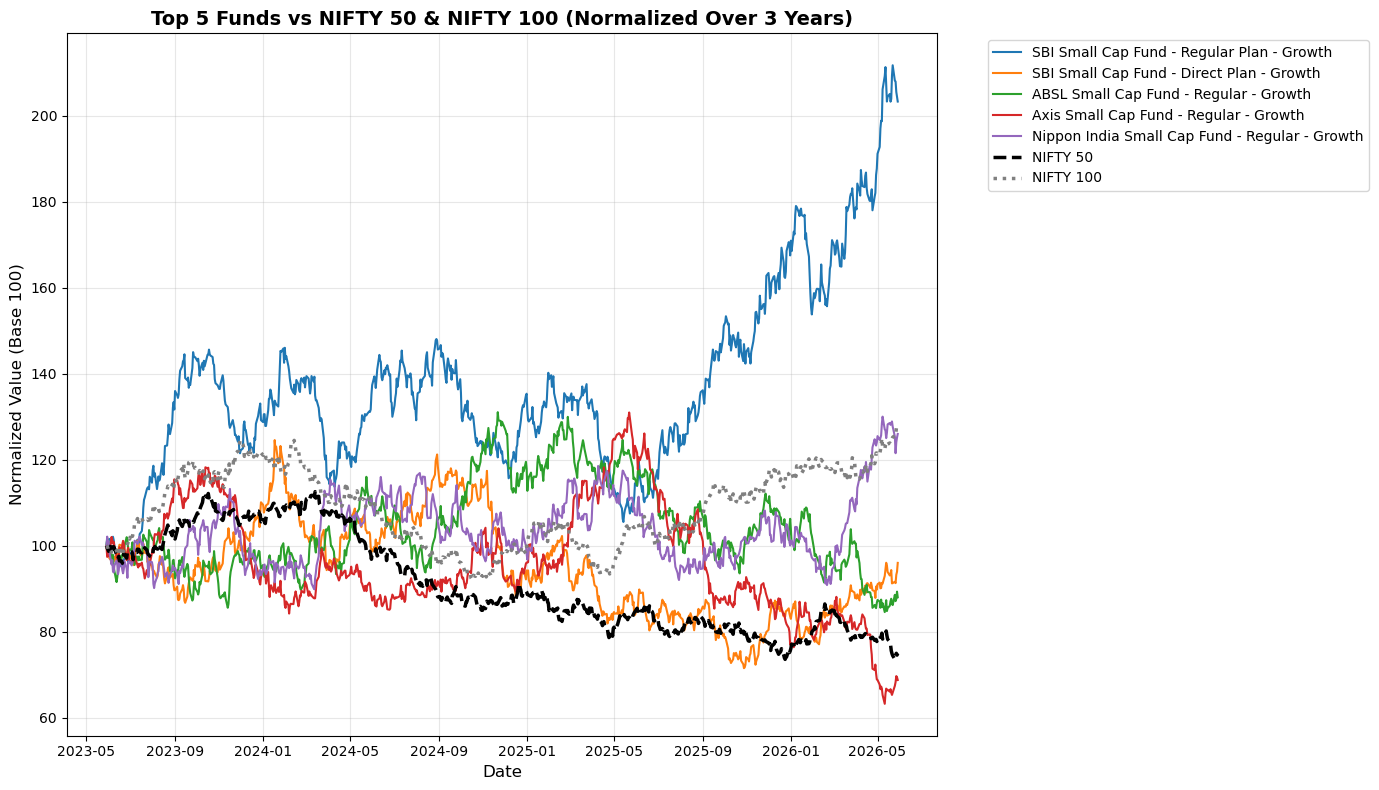

In [75]:
# Convert tracking errors to a DataFrame and save as CSV
te_df = pd.DataFrame(tracking_errors)
te_df.to_csv('tracking_errors.csv', index=False)
print("Tracking Error metrics successfully calculated and saved to 'tracking_errors.csv'.")
print(te_df)

# ==========================================
# 5. Normalize Data & Generate the Chart
# ==========================================
# Normalize both funds and indices to a base value of 100 starting at the first date
normalized = (combined / combined.iloc[0]) * 100

plt.figure(figsize=(14, 8))

# Plot top 5 funds
for code in top_5_codes:
    plt.plot(normalized.index, normalized[code], label=fund_names[code], linewidth=1.5)

# Plot benchmark lines with distinct weight and styles
plt.plot(normalized.index, normalized['NIFTY50'], label='NIFTY 50', linewidth=2.5, color='black', linestyle='--')
plt.plot(normalized.index, normalized['NIFTY100'], label='NIFTY 100', linewidth=2.5, color='grey', linestyle=':')

# Chart formatting
plt.title('Top 5 Funds vs NIFTY 50 & NIFTY 100 (Normalized Over 3 Years)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Normalized Value (Base 100)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()